# Customer Churn Analysis (EDA Project)
Author: Deo Reji  
**Tools: Python, pandas, seaborn, matplotlib  

## Dataset
The dataset includes customer information such as:

- Demographics: `gender`, `age`, `city`, `country`  
- Account details: `tenure_months`, `contract_type`, `signup_channel`  
- Engagement metrics: `monthly_logins`, `weekly_active_days`, `avg_session_time`, `features_used`  
- Business metrics: `monthly_fee`, `total_revenue`, `churn`  
- Customer feedback: `csat_score`, `nps_score`, `survey_response`

This is my first solo project so I am including me testing things out to show my progression in learning through building.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/raw/customer_churn_business_dataset.csv")

df.head()

,customer_id,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,...,avg_resolution_time,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn
0,CUST_00001,Male,68,Bangladesh,London,SME,22,Web,Monthly,26,...,13.354360,Service,4.0,0,0.71,0.40,27,Satisfied,1,0
1,CUST_00002,Female,57,Canada,Sydney,Individual,9,Mobile,Monthly,7,...,25.140088,Billing,2.0,0,0.78,0.33,-19,Neutral,2,1
2,CUST_00003,Male,24,Germany,New York,SME,58,Web,Yearly,19,...,27.572928,Service,3.0,0,0.35,0.49,80,Neutral,1,0
3,CUST_00004,Male,49,Australia,Dhaka,Individual,19,Mobile,Yearly,34,...,26.420822,Technical,5.0,1,0.83,0.15,100,Neutral,0,0
4,CUST_00005,Male,65,Bangladesh,Delhi,Individual,52,Web,Monthly,20,...,26.674579,Technical,4.0,0,0.65,0.44,21,Unsatisfied,1,0


In [3]:
df.shape

(10000, 32)

In [4]:
df.columns

Index(['customer_id', 'gender', 'age', 'country', 'city', 'customer_segment',
       'tenure_months', 'signup_channel', 'contract_type', 'monthly_logins',
       'weekly_active_days', 'avg_session_time', 'features_used',
       'usage_growth_rate', 'last_login_days_ago', 'monthly_fee',
       'total_revenue', 'payment_method', 'payment_failures',
       'discount_applied', 'price_increase_last_3m', 'support_tickets',
       'avg_resolution_time', 'complaint_type', 'csat_score', 'escalations',
       'email_open_rate', 'marketing_click_rate', 'nps_score',
       'survey_response', 'referral_count', 'churn'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             10000 non-null  object 
 1   gender                  10000 non-null  object 
 2   age                     10000 non-null  int64  
 3   country                 10000 non-null  object 
 4   city                    10000 non-null  object 
 5   customer_segment        10000 non-null  object 
 6   tenure_months           10000 non-null  int64  
 7   signup_channel          10000 non-null  object 
 8   contract_type           10000 non-null  object 
 9   monthly_logins          10000 non-null  int64  
 10  weekly_active_days      10000 non-null  int64  
 11  avg_session_time        10000 non-null  float64
 12  features_used           10000 non-null  int64  
 13  usage_growth_rate       10000 non-null  float64
 14  last_login_days_ago     10000 non-null 

In [6]:
df.describe()

,age,tenure_months,monthly_logins,weekly_active_days,avg_session_time,features_used,usage_growth_rate,last_login_days_ago,monthly_fee,total_revenue,payment_failures,support_tickets,avg_resolution_time,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,referral_count,churn
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0000,10000.000000
mean,45.906100,30.155700,19.672000,3.479400,15.187890,4.990800,0.019423,9.505200,34.930000,1057.018000,0.501000,1.206600,23.953210,3.486700,0.294100,0.499610,0.253575,19.110500,0.9922,0.102100
std,16.420416,17.099517,9.838003,2.302283,6.830774,2.211607,0.149567,9.799417,23.785115,1020.148233,0.711934,1.104554,9.956999,0.978631,0.543171,0.231601,0.140532,38.936619,0.9939,0.302795
min,18.000000,1.000000,0.000000,0.000000,1.000000,1.000000,-0.580000,0.000000,10.000000,10.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.100000,0.010000,-100.000000,0.0000,0.000000
25%,32.000000,16.000000,13.000000,1.000000,10.391645,3.000000,-0.080000,2.000000,20.000000,340.000000,0.000000,0.000000,17.082041,3.000000,0.000000,0.300000,0.130000,-7.000000,0.0000,0.000000
50%,46.000000,30.000000,20.000000,3.000000,15.161659,5.000000,0.020000,6.000000,30.000000,720.000000,0.000000,1.000000,23.950444,4.000000,0.000000,0.500000,0.250000,19.000000,1.0000,0.000000
75%,60.000000,45.000000,26.000000,5.000000,19.882034,6.000000,0.120000,13.000000,50.000000,1440.000000,1.000000,2.000000,30.758480,4.000000,1.000000,0.700000,0.380000,46.000000,2.0000,0.000000
max,74.000000,59.000000,54.000000,7.000000,41.996411,15.000000,0.540000,80.000000,100.000000,5900.000000,5.000000,7.000000,61.821878,5.000000,4.000000,0.900000,0.500000,100.000000,7.0000,1.000000


In [7]:
df["churn"].value_counts()

churn
0    8979
1    1021
Name: count, dtype: int64

In [8]:
df["churn"].value_counts(normalize=True)

churn
0    0.8979
1    0.1021
Name: proportion, dtype: float64

In [9]:
df["tenure_months"].describe()

count    10000.000000
mean        30.155700
std         17.099517
min          1.000000
25%         16.000000
50%         30.000000
75%         45.000000
max         59.000000
Name: tenure_months, dtype: float64

In [10]:
df.groupby("churn")["tenure_months"].mean()

churn
0    30.830382
1    24.222331
Name: tenure_months, dtype: float64

Here is one possible factor to customer churn

<Axes: title={'center': 'tenure_months'}, xlabel='churn'>

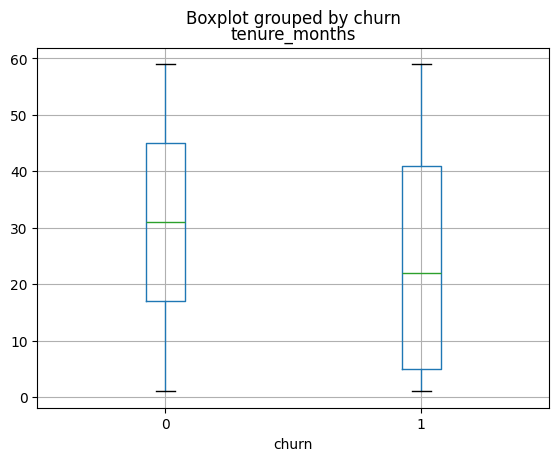

In [11]:
df.boxplot(column="tenure_months", by="churn")

In [12]:
df["monthly_fee"].describe()

count    10000.000000
mean        34.930000
std         23.785115
min         10.000000
25%         20.000000
50%         30.000000
75%         50.000000
max        100.000000
Name: monthly_fee, dtype: float64

In [13]:
df.groupby("churn")["monthly_fee"].mean()

churn
0    34.970487
1    34.573947
Name: monthly_fee, dtype: float64

In [14]:
df["contract_type"].value_counts()

contract_type
Monthly      4967
Quarterly    3050
Yearly       1983
Name: count, dtype: int64

In [15]:
df.groupby("contract_type")["churn"].mean()

contract_type
Monthly      0.103282
Quarterly    0.099344
Yearly       0.103379
Name: churn, dtype: float64

In [16]:
df.columns

Index(['customer_id', 'gender', 'age', 'country', 'city', 'customer_segment',
       'tenure_months', 'signup_channel', 'contract_type', 'monthly_logins',
       'weekly_active_days', 'avg_session_time', 'features_used',
       'usage_growth_rate', 'last_login_days_ago', 'monthly_fee',
       'total_revenue', 'payment_method', 'payment_failures',
       'discount_applied', 'price_increase_last_3m', 'support_tickets',
       'avg_resolution_time', 'complaint_type', 'csat_score', 'escalations',
       'email_open_rate', 'marketing_click_rate', 'nps_score',
       'survey_response', 'referral_count', 'churn'],
      dtype='object')

In [17]:
import pandas as pd
df = pd.read_csv("../data/raw/customer_churn_business_dataset.csv")
df["monthly_logins"].value_counts()

monthly_logins
17    411
21    401
23    397
22    397
19    386
18    385
20    375
16    373
25    373
24    364
15    347
14    336
13    332
12    326
0     299
27    290
28    288
29    274
10    261
26    257
11    252
30    226
9     221
8     215
31    194
32    191
6     176
7     163
33    162
35    128
5     125
34    122
4     111
36    106
3      99
37     87
2      81
38     79
1      78
39     66
40     55
41     36
42     35
44     28
43     27
45     16
46     14
47     12
49      7
51      6
48      5
50      4
54      1
Name: count, dtype: int64

In [18]:
df.columns

Index(['customer_id', 'gender', 'age', 'country', 'city', 'customer_segment',
       'tenure_months', 'signup_channel', 'contract_type', 'monthly_logins',
       'weekly_active_days', 'avg_session_time', 'features_used',
       'usage_growth_rate', 'last_login_days_ago', 'monthly_fee',
       'total_revenue', 'payment_method', 'payment_failures',
       'discount_applied', 'price_increase_last_3m', 'support_tickets',
       'avg_resolution_time', 'complaint_type', 'csat_score', 'escalations',
       'email_open_rate', 'marketing_click_rate', 'nps_score',
       'survey_response', 'referral_count', 'churn'],
      dtype='object')

In [19]:
df.groupby("churn")["monthly_logins"].mean()

churn
0    19.998218
1    16.803134
Name: monthly_logins, dtype: float64

Found a second possible factor of churn, will test more but I feel like I am at a good point here

In [20]:
df.groupby("churn")["weekly_active_days"].mean()

churn
0    3.486246
1    3.419197
Name: weekly_active_days, dtype: float64

In [21]:
df.groupby("churn")["avg_session_time"].mean()

churn
0    15.198622
1    15.093508
Name: avg_session_time, dtype: float64

In [22]:
df.groupby("churn")["last_login_days_ago"].mean()

churn
0     9.382114
1    10.587659
Name: last_login_days_ago, dtype: float64

In [23]:
df.groupby("churn")["csat_score"].mean()

churn
0    3.538813
1    3.028404
Name: csat_score, dtype: float64

In [24]:
df.groupby("churn")["nps_score"].mean()

churn
0    19.071166
1    19.456415
Name: nps_score, dtype: float64

Hypothesis:
Customers with shorter tenure and lower engagement (monthly logins) have a significantly higher probability of churn.

In [25]:
df['login_bucket'] = pd.qcut(
    df['monthly_logins'],
    q=4,
    labels=['Low', 'Medium', 'High', 'Very High']
)

In [26]:
df['login_bucket'].value_counts()

login_bucket
Low          2739
Medium       2613
Very High    2459
High         2189
Name: count, dtype: int64

In [27]:
df.groupby('login_bucket')['churn'].mean()

C:\Users\rejid\AppData\Local\Temp\ipykernel_32440\3028661294.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('login_bucket')['churn'].mean()


login_bucket
Low          0.143118
Medium       0.090318
High         0.089082
Very High    0.080521
Name: churn, dtype: float64

Low engagement users churn at a 14% rate

In [28]:
df['tenure_bucket'] = pd.cut(
    df['tenure_months'],
    bins=[0, 6, 12, 24, 36, df['tenure_months'].max()],
    labels=['0–6', '6–12', '12–24', '24–36', '36+']
)

In [29]:
df['tenure_bucket'].value_counts()

tenure_bucket
36+      3914
24–36    2049
12–24    1987
0–6      1032
6–12     1018
Name: count, dtype: int64

We group the users by tenures to compare

In [30]:
df.groupby(['tenure_bucket', 'login_bucket'])['churn'].mean()

C:\Users\rejid\AppData\Local\Temp\ipykernel_32440\2448353515.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['tenure_bucket', 'login_bucket'])['churn'].mean()


tenure_bucket  login_bucket
0–6            Low             0.307692
               Medium          0.306513
               High            0.282051
               Very High       0.227273
6–12           Low             0.131579
               Medium          0.072519
               High            0.087719
               Very High       0.061069
12–24          Low             0.137500
               Medium          0.070588
               High            0.042155
               Very High       0.087755
24–36          Low             0.127660
               Medium          0.065217
               High            0.055172
               Very High       0.058233
36+            Low             0.115242
               Medium          0.063230
               High            0.077457
               Very High       0.052910
Name: churn, dtype: float64

0–6 months + Low engagement ≈ 30% churn

Now lets create a heatmap to represent the churn rate

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

In [32]:
login_order = ['Low', 'Medium', 'High', 'Very High']

churn_matrix = df.groupby(['tenure_bucket', 'login_bucket'])['churn'].mean().unstack()
churn_matrix = churn_matrix[login_order]  

C:\Users\rejid\AppData\Local\Temp\ipykernel_32440\1349536370.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_matrix = df.groupby(['tenure_bucket', 'login_bucket'])['churn'].mean().unstack()


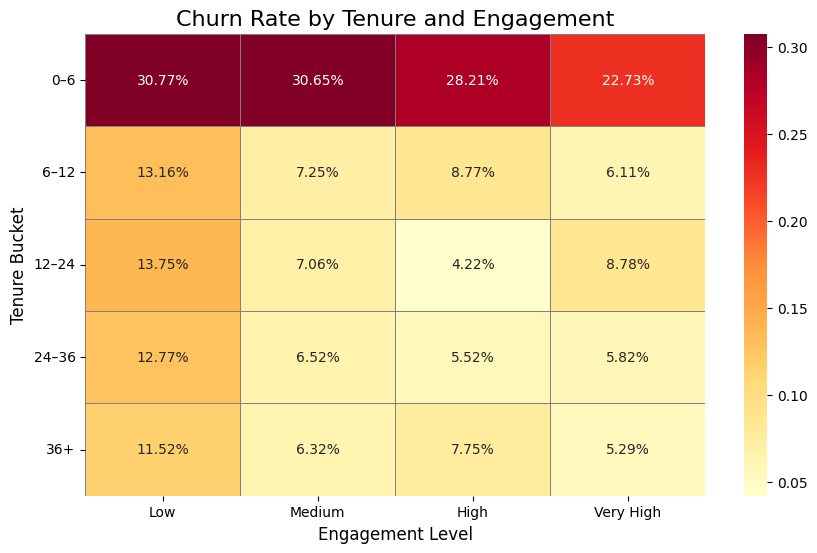

In [33]:
plt.figure(figsize=(10,6))
sns.heatmap(churn_matrix, annot=True, fmt=".2%", cmap="YlOrRd", linewidths=0.5, linecolor='gray'
)
plt.title("Churn Rate by Tenure and Engagement", fontsize=16)
plt.ylabel("Tenure Bucket", fontsize=12)
plt.xlabel("Engagement Level", fontsize=12)
plt.xticks(rotation=0) 
plt.yticks(rotation=0)
plt.show()

Making a copy of the processed data to put into Power Bi

In [35]:
import os

os.makedirs("processed_data", exist_ok=True)

df.to_csv("../data/processed/churn_bi_data.csv", index=False)


Customer Churn EDA: Key Insights

1. The early stage customers are high-risk.
-- The customers in the 0-6 month range have the highest churn rate, especially if their engagement is low. This is represented by the darker colors showing higher churn rate.
-- For example, low-engagement new users churn around 30%, compared to around 5% for highly engaged long-term users.

2. User engagement matters the most very early.
-- In the first year the engagement difference are the most impactful.
-- After 24-36 months, churn is gnerally low regardless of engagment.

3. Business thoughts and implications.
-- Focus on retention initiatives for new users like onboarding campaings, encouraging early feature usage, and incentives during the first 90 days.

4. Visualization
-- The heatmap below shows churn by tenure bucket (rows) and engagement level (columns).
-- Darker red = higher churn. Clear patterns emerge showing early low-engagement users are most likely to leave.